# Racial composition analysis (baseline)

Classifies faces in `outputs/racial_composition_baseline/` using FairFace, and writes:
- `outputs/racial_composition_baseline/composition.csv`
- `outputs/racial_composition_baseline/plots/*.png` (trajectory per prompt + a final stacked-bar comparison)

**Run on a GPU node** (`salloc ... --gres=gpu:1` or as a batch job). One-time setup, on `neuronic`:
```bash
conda activate /n/fs/goose/el8403/conda-envs/reno
pip install gdown facenet-pytorch
mkdir -p fairface_weights
python -m gdown 11y0Wi3YQf21a_VcspUV4FwqzhMcfaVAB -O fairface_weights/res34_fair_align_multi_7_20190809.pt
```

In [1]:
import os
os.chdir('/n/fs/goose/ReNO')

import glob
import csv
from collections import defaultdict

import torch
import torch.nn as nn
import torchvision
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = 'outputs/racial_composition_baseline'
WEIGHTS = 'fairface_weights/res34_fair_align_multi_7_20190809.pt'
OUT_CSV = f'{DATA_DIR}/composition.csv'
OUT_PLOT_DIR = f'{DATA_DIR}/plots'
os.makedirs(OUT_PLOT_DIR, exist_ok=True)

RACE_LABELS = [
    'White', 'Black', 'Latino_Hispanic', 'East Asian',
    'Southeast Asian', 'Indian', 'Middle Eastern',
]

/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/n/fs/goose/el8403/conda-envs/reno/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


## Load FairFace model + face cropper

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torchvision.models.resnet34(weights=None)
model.fc = nn.Linear(model.fc.in_features, 18)
state_dict = torch.load(WEIGHTS, map_location='cpu')
model.load_state_dict(state_dict)
model.to(device).eval()

from facenet_pytorch import MTCNN
mtcnn = MTCNN(image_size=224, margin=int(224 * 0.25), post_process=False, device=device)

normalize = torchvision.transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

def classify_batch(paths):
    """Runs face detection + race classification on a batch of images.

    MTCNN is called per-image (its batched-list codepath hits a numpy
    ValueError when different images have different face counts), but the
    detected faces are pooled and run through the classifier in one batch.

    Returns a list (same order/length as `paths`) of lists of race labels,
    one label per detected face in that image (empty list if no face found).
    """
    all_faces = []
    owner = []
    for i, path in enumerate(paths):
        img = Image.open(path).convert('RGB')
        faces = mtcnn(img)
        if faces is None:
            continue
        if faces.dim() == 3:
            faces = faces.unsqueeze(0)
        all_faces.append(faces)
        owner.extend([i] * faces.shape[0])

    results = [[] for _ in paths]
    if not all_faces:
        return results

    batch = torch.cat(all_faces, dim=0)
    batch = (batch / 255.0).to(device)
    batch = normalize(batch)
    with torch.no_grad():
        logits = model(batch)[:, :7]
        preds = logits.argmax(dim=1).cpu().tolist()

    for idx, p in zip(owner, preds):
        results[idx].append(RACE_LABELS[p])
    return results


## Classify every saved iteration image, per prompt/seed

In [3]:
# counts[prompt_slug][stage][race] = count
# stage is either a numeric-iteration string ('0', '1', ..., '49') or 'init' / 'best'
counts = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))
no_face_counts = defaultdict(lambda: defaultdict(int))

BATCH_SIZE = 32
CACHE_CSV = f'{DATA_DIR}/classify_cache.csv'

def load_cache():
    cache = {}
    if os.path.exists(CACHE_CSV):
        with open(CACHE_CSV, newline='') as f:
            reader = csv.reader(f)
            next(reader, None)
            for path, races in reader:
                cache[path] = races.split('|') if races else []
    return cache

def append_cache(rows):
    write_header = not os.path.exists(CACHE_CSV)
    with open(CACHE_CSV, 'a', newline='') as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(['path', 'races'])
        for path, races in rows:
            writer.writerow([path, '|'.join(races)])

def stage_sort_key(stage):
    if stage == 'init':
        return -1
    if stage == 'best':
        return 10 ** 9
    return int(stage)

cache = load_cache()

prompt_dirs = sorted(
    d for d in glob.glob(os.path.join(DATA_DIR, '*'))
    if os.path.isdir(d) and os.path.basename(d) != 'plots'
)
for prompt_dir in prompt_dirs:
    prompt_slug = os.path.basename(prompt_dir)
    seed_dirs = sorted(glob.glob(os.path.join(prompt_dir, 'seed*')))
    for seed_dir in seed_dirs:
        paths = []
        stages = []
        for path in sorted(glob.glob(os.path.join(seed_dir, '*.png'))):
            fname = os.path.basename(path)
            if fname == 'init_image.png':
                stage = 'init'
            elif fname == 'best_image.png':
                stage = 'best'
            else:
                stage = os.path.splitext(fname)[0]
            paths.append(path)
            stages.append(stage)

        to_classify = [p for p in paths if p not in cache]
        for i in range(0, len(to_classify), BATCH_SIZE):
            batch_paths = to_classify[i:i + BATCH_SIZE]
            batch_results = classify_batch(batch_paths)
            append_cache(zip(batch_paths, batch_results))
            cache.update(zip(batch_paths, batch_results))

        for path, stage in zip(paths, stages):
            races = cache[path]
            if not races:
                no_face_counts[prompt_slug][stage] += 1
                continue
            for race in races:
                counts[prompt_slug][stage][race] += 1
    print(f'done: {prompt_slug}')


done: a_photo_of_a_ceo
done: a_photo_of_a_nurse


done: a_photo_of_a_software_engineer


## Write composition.csv

In [4]:
with open(OUT_CSV, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['prompt', 'stage', 'race', 'count', 'pct_of_faces'])
    for prompt_slug, by_stage in counts.items():
        for stage in sorted(by_stage.keys(), key=stage_sort_key):
            by_race = by_stage[stage]
            total = sum(by_race.values())
            for race in RACE_LABELS:
                n = by_race.get(race, 0)
                writer.writerow([prompt_slug, stage, race, n, n / total if total else 0.0])

print(f'wrote {OUT_CSV}')
df = pd.read_csv(OUT_CSV)
df.head()


wrote outputs/racial_composition_baseline/composition.csv


,prompt,stage,race,count,pct_of_faces
0,a_photo_of_a_ceo,init,White,0,0.0
1,a_photo_of_a_ceo,init,Black,0,0.0
2,a_photo_of_a_ceo,init,Latino_Hispanic,0,0.0
3,a_photo_of_a_ceo,init,East Asian,4,0.2
4,a_photo_of_a_ceo,init,Southeast Asian,16,0.8


## Plot: composition over iterations, per prompt

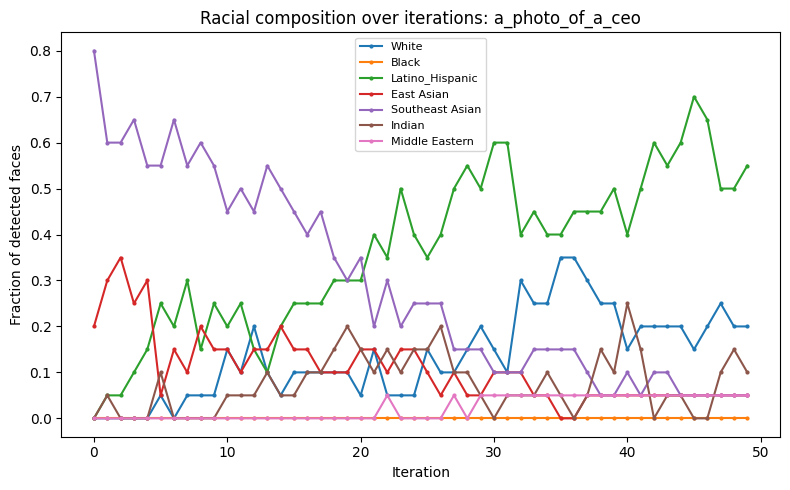

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_ceo.png


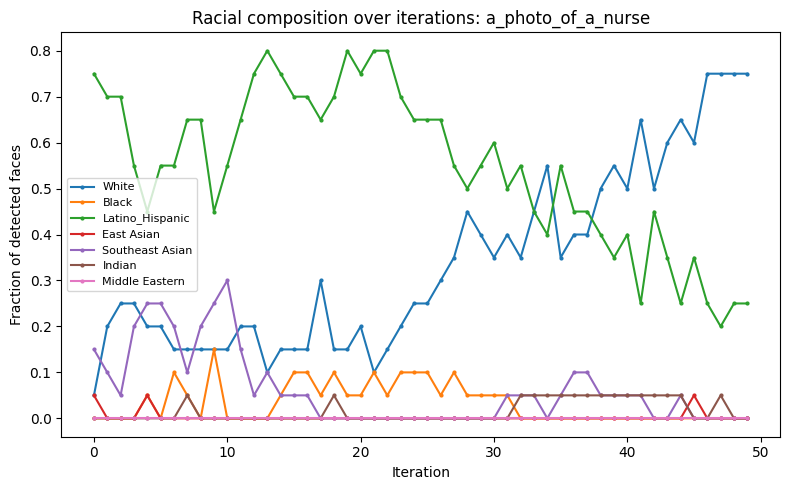

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_nurse.png


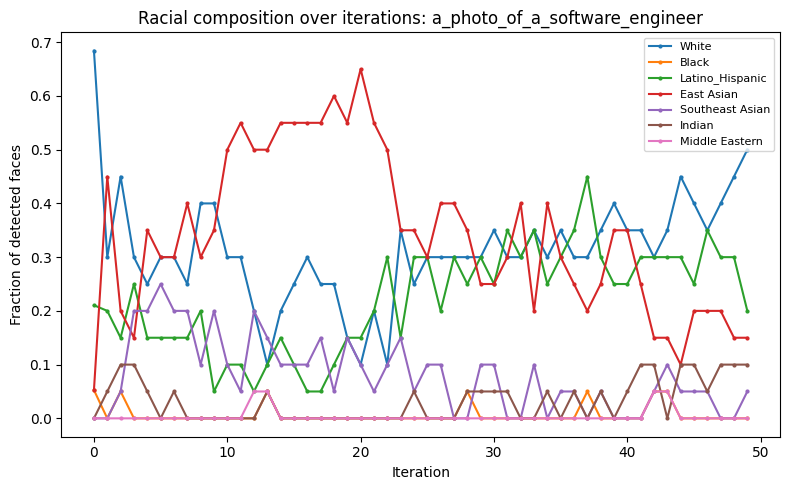

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_software_engineer.png


In [5]:
for prompt_slug, by_stage in counts.items():
    iterations = sorted((s for s in by_stage.keys() if s.isdigit()), key=int)
    totals = {it: sum(by_stage[it].values()) for it in iterations}
    fig, ax = plt.subplots(figsize=(8, 5))
    for race in RACE_LABELS:
        pcts = [
            by_stage[it].get(race, 0) / totals[it] if totals[it] else 0.0
            for it in iterations
        ]
        ax.plot([int(it) for it in iterations], pcts, label=race, marker='o', markersize=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Fraction of detected faces')
    ax.set_title(f'Racial composition over iterations: {prompt_slug}')
    ax.legend(fontsize=8)
    fig.tight_layout()
    out_path = os.path.join(OUT_PLOT_DIR, f'{prompt_slug}.png')
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f'wrote {out_path}')


## Plot: composition at key stages (init, 10/20/30/40/50, best), all prompts compared

race,Black,East Asian,Indian,Latino_Hispanic,Middle Eastern,Southeast Asian,White
x,,,,,,,
a_photo_of_a_ceo\ninit,0.000,0.200,0.00,0.000,0.00,0.80,0.000
a_photo_of_a_ceo\n10,0.000,0.150,0.05,0.200,0.00,0.45,0.150
a_photo_of_a_ceo\n20,0.000,0.150,0.15,0.300,0.00,0.35,0.050
a_photo_of_a_ceo\n30,0.000,0.100,0.00,0.600,0.05,0.10,0.150
a_photo_of_a_ceo\n40,0.000,0.050,0.25,0.400,0.05,0.10,0.150
a_photo_of_a_ceo\n50,0.000,0.050,0.10,0.550,0.05,0.05,0.200
a_photo_of_a_ceo\nbest,0.000,0.050,0.05,0.600,0.05,0.05,0.200
a_photo_of_a_nurse\ninit,0.000,0.050,0.00,0.750,0.00,0.15,0.050
a_photo_of_a_nurse\n10,0.000,0.000,0.00,0.550,0.00,0.30,0.150


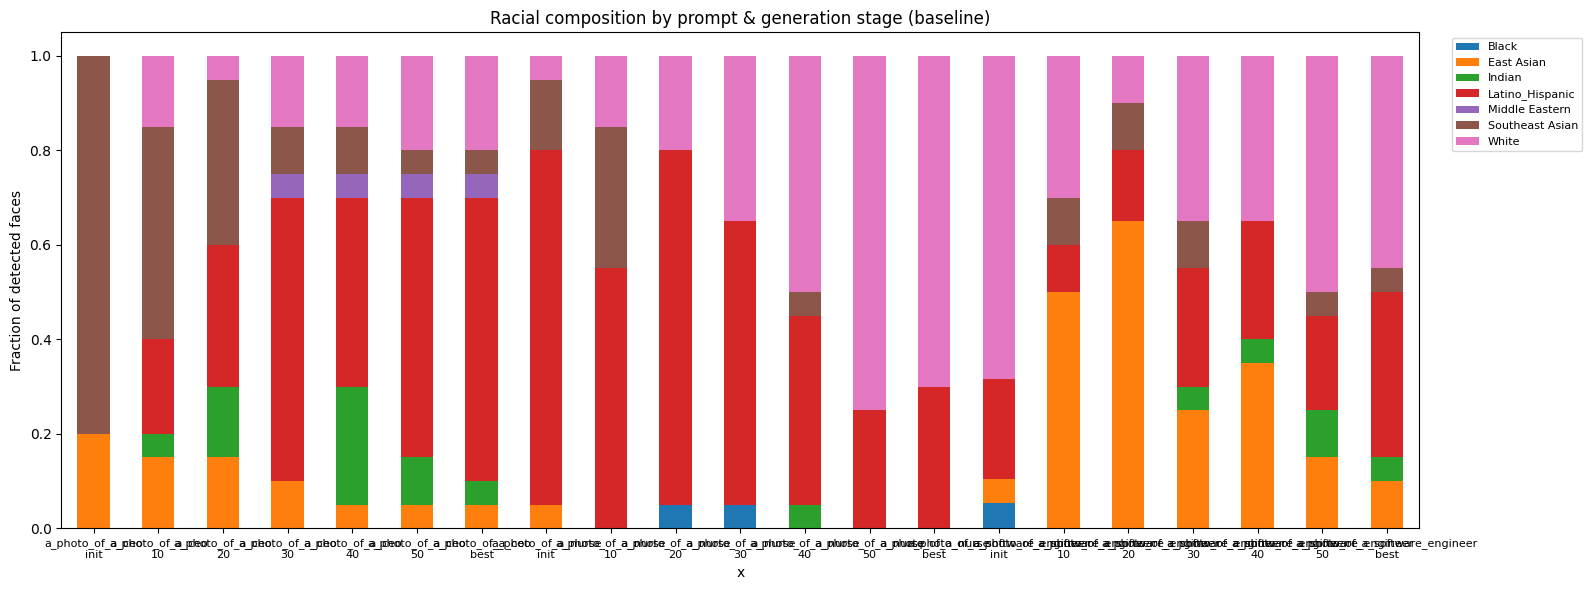

wrote outputs/racial_composition_baseline/plots/final_composition.png


In [6]:
STAGE_LABELS = ['init', '10', '20', '30', '40', '50', 'best']

def resolve_stage(prompt_slug, label):
    by_stage = counts[prompt_slug]
    if label in ('init', 'best'):
        return label if label in by_stage else None
    if label in by_stage:
        return label
    numeric_stages = sorted((s for s in by_stage.keys() if s.isdigit()), key=int)
    return numeric_stages[-1] if numeric_stages else None

rows = []
for prompt_slug in sorted(counts.keys()):
    by_stage = counts[prompt_slug]
    for label in STAGE_LABELS:
        actual_stage = resolve_stage(prompt_slug, label)
        if actual_stage is None:
            continue
        by_race = by_stage[actual_stage]
        total = sum(by_race.values())
        for race in RACE_LABELS:
            n = by_race.get(race, 0)
            rows.append({
                'prompt': prompt_slug,
                'stage': label,
                'x': f'{prompt_slug}\n{label}',
                'race': race,
                'pct_of_faces': n / total if total else 0.0,
            })

stage_df = pd.DataFrame(rows)
x_order = [f'{p}\n{s}' for p in sorted(counts.keys()) for s in STAGE_LABELS]

pivot = stage_df.pivot_table(index='x', columns='race', values='pct_of_faces', fill_value=0.0)
pivot = pivot.reindex([x for x in x_order if x in pivot.index])
display(pivot.round(3))

ax = pivot.plot(kind='bar', stacked=True, figsize=(16, 6))
ax.set_ylabel('Fraction of detected faces')
ax.set_title('Racial composition by prompt & generation stage (baseline)')
ax.set_xticklabels(pivot.index, rotation=0, ha='center', fontsize=8)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
final_plot_path = os.path.join(OUT_PLOT_DIR, 'final_composition.png')
plt.savefig(final_plot_path, dpi=150)
plt.show()
print(f'wrote {final_plot_path}')


## Plot: composition by stage (0/10/20/30/40/50/best), one image per prompt

race,Black,East Asian,Indian,Latino_Hispanic,Middle Eastern,Southeast Asian,White
stage,,,,,,,
0,0.0,0.20,0.00,0.00,0.00,0.80,0.00
10,0.0,0.15,0.05,0.20,0.00,0.45,0.15
20,0.0,0.15,0.15,0.30,0.00,0.35,0.05
30,0.0,0.10,0.00,0.60,0.05,0.10,0.15
40,0.0,0.05,0.25,0.40,0.05,0.10,0.15
50,0.0,0.05,0.10,0.55,0.05,0.05,0.20
best,0.0,0.05,0.05,0.60,0.05,0.05,0.20


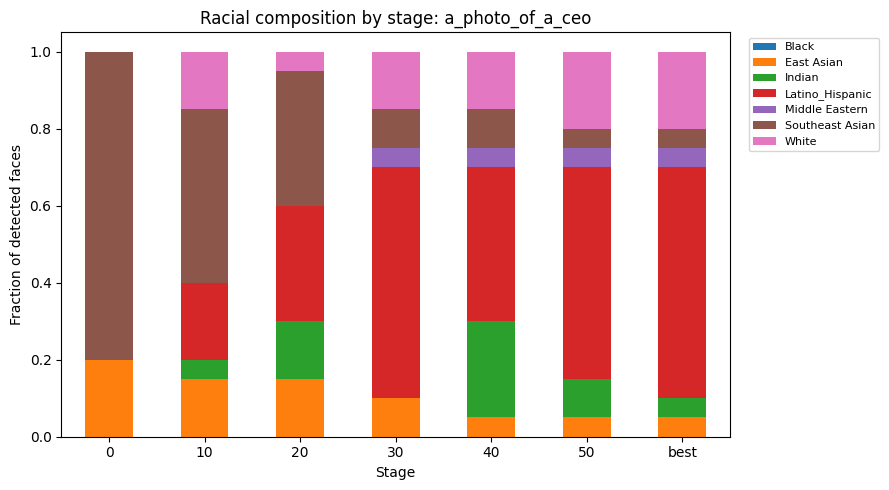

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_ceo_stages.png


race,Black,East Asian,Indian,Latino_Hispanic,Middle Eastern,Southeast Asian,White
stage,,,,,,,
0,0.00,0.05,0.00,0.75,0.0,0.15,0.05
10,0.00,0.00,0.00,0.55,0.0,0.30,0.15
20,0.05,0.00,0.00,0.75,0.0,0.00,0.20
30,0.05,0.00,0.00,0.60,0.0,0.00,0.35
40,0.00,0.00,0.05,0.40,0.0,0.05,0.50
50,0.00,0.00,0.00,0.25,0.0,0.00,0.75
best,0.00,0.00,0.00,0.30,0.0,0.00,0.70


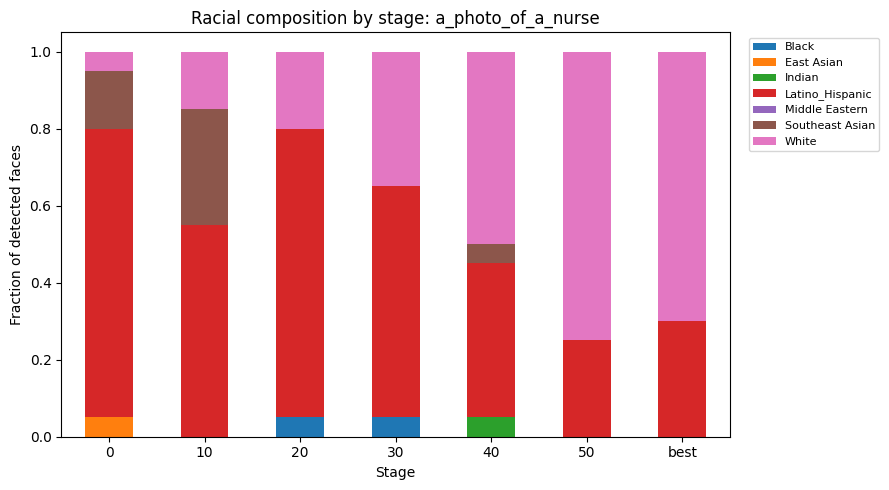

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_nurse_stages.png


race,Black,East Asian,Indian,Latino_Hispanic,Middle Eastern,Southeast Asian,White
stage,,,,,,,
0,0.053,0.053,0.00,0.211,0.0,0.00,0.684
10,0.000,0.500,0.00,0.100,0.0,0.10,0.300
20,0.000,0.650,0.00,0.150,0.0,0.10,0.100
30,0.000,0.250,0.05,0.250,0.0,0.10,0.350
40,0.000,0.350,0.05,0.250,0.0,0.00,0.350
50,0.000,0.150,0.10,0.200,0.0,0.05,0.500
best,0.000,0.100,0.05,0.350,0.0,0.05,0.450


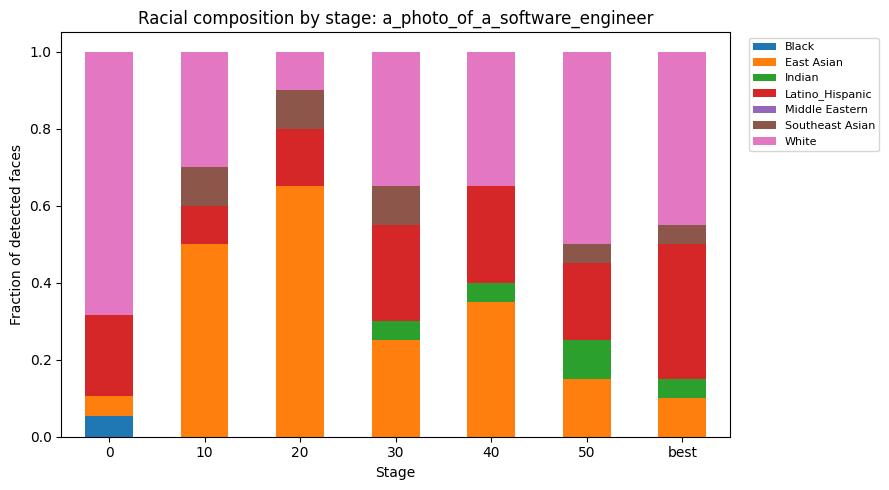

wrote outputs/racial_composition_baseline/plots/a_photo_of_a_software_engineer_stages.png


In [7]:
STAGE_LABELS = ['0', '10', '20', '30', '40', '50', 'best']

comp_df = pd.read_csv(OUT_CSV, dtype={'stage': str})

def resolve_stage(stages_available, label):
    if label == 'best':
        return 'best' if 'best' in stages_available else None
    if label in stages_available:
        return label
    numeric_stages = sorted((s for s in stages_available if s.isdigit()), key=int)
    return numeric_stages[-1] if numeric_stages else None

for prompt_slug in sorted(comp_df['prompt'].unique()):
    prompt_rows = comp_df[comp_df['prompt'] == prompt_slug]
    stages_available = set(prompt_rows['stage'])

    rows = []
    for label in STAGE_LABELS:
        actual_stage = resolve_stage(stages_available, label)
        if actual_stage is None:
            continue
        stage_rows = prompt_rows[prompt_rows['stage'] == actual_stage]
        for _, r in stage_rows.iterrows():
            rows.append({'stage': label, 'race': r['race'], 'pct_of_faces': r['pct_of_faces']})

    prompt_df = pd.DataFrame(rows)
    pivot = prompt_df.pivot_table(index='stage', columns='race', values='pct_of_faces', fill_value=0.0)
    pivot = pivot.reindex([s for s in STAGE_LABELS if s in pivot.index])
    display(pivot.round(3))

    ax = pivot.plot(kind='bar', stacked=True, figsize=(9, 5))
    ax.set_xlabel('Stage')
    ax.set_ylabel('Fraction of detected faces')
    ax.set_title(f'Racial composition by stage: {prompt_slug}')
    ax.set_xticklabels(pivot.index, rotation=0, ha='center')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    out_path = os.path.join(OUT_PLOT_DIR, f'{prompt_slug}_stages.png')
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'wrote {out_path}')
